# Local LLM Lab Research Dashboard

This notebook aggregates and visualizes the experiments run in the Local LLM Lab framework.

In [4]:
import pandas as pd
from IPython.display import display, Image, HTML
from pathlib import Path
import os

# Ensure we are in the project root
if Path.cwd().name == 'notebooks':
    os.chdir('..')

from llm_lab.reporting.dashboard import aggregate_experiments

# Re-run aggregation to ensure data is fresh
aggregate_experiments()

Aggregated 6 experiments into D:\Github_Clones\local-llm-lab\reports\experiment_log.csv
Generating plots...
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\pass_1_vs_exp.png
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\pass_4_vs_exp.png
Metric ood_pass_at_1 not found or empty in data, skipping plot.
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\task_completion_rate_vs_exp.png
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\steps_to_success_vs_exp.png
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\recovery_rate_vs_exp.png
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\roi_gain_per_gpu_hour.png
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\hardware_util.png
Plot saved to D:\Github_Clones\local-llm-lab\reports\figures\reward_vs_step.png
Dashboard generation complete.


## Experiment Log

Below is the comprehensive log of all tracked experiments.

In [5]:
csv_path = Path("reports/experiment_log.csv")
if csv_path.exists():
    df = pd.read_csv(csv_path)
    # Display the most relevant columns
    display_cols = [c for c in ['experiment_id', 'date', 'model', 'method', 'pass_at_1', 'pass_at_4', 'task_completion_rate', 'gpu_hours', 'peak_vram_gb'] if c in df.columns]
    display(df[display_cols].sort_values('date', ascending=False))
else:
    print("Experiment log not found.")

,experiment_id,date,model,method,pass_at_1,pass_at_4,task_completion_rate,gpu_hours,peak_vram_gb
5,exp04_search_complex,2026-09-10T02:23:38Z,Qwen/Qwen3.5-2B,eval,0.029375,0.059555,NaN,0.000000,1.765630
4,exp02_grpo_v1_5k_eval,2026-09-07T03:18:48Z,Qwen/Qwen3.5-2B,eval,1.000000,1.000000,NaN,45.000000,5.110000
3,exp01_sft_v1_eval,2026-09-04T08:05:17Z,Qwen/Qwen3.5-2B,eval,1.000000,1.000000,NaN,3.040408,3.975474
2,exp00_eval,2026-09-04T04:07:46Z,Qwen/Qwen3.5-2B,eval,1.000000,NaN,NaN,0.000000,1.720940
0,exp05_agent_2b,NaN,NaN,eval,NaN,NaN,0.2,0.000000,NaN
1,exp05_agent_4b,NaN,NaN,eval,NaN,NaN,0.3,0.000000,NaN


## Research Figures

The figures below demonstrate the comparative capabilities and efficiencies of our approaches.

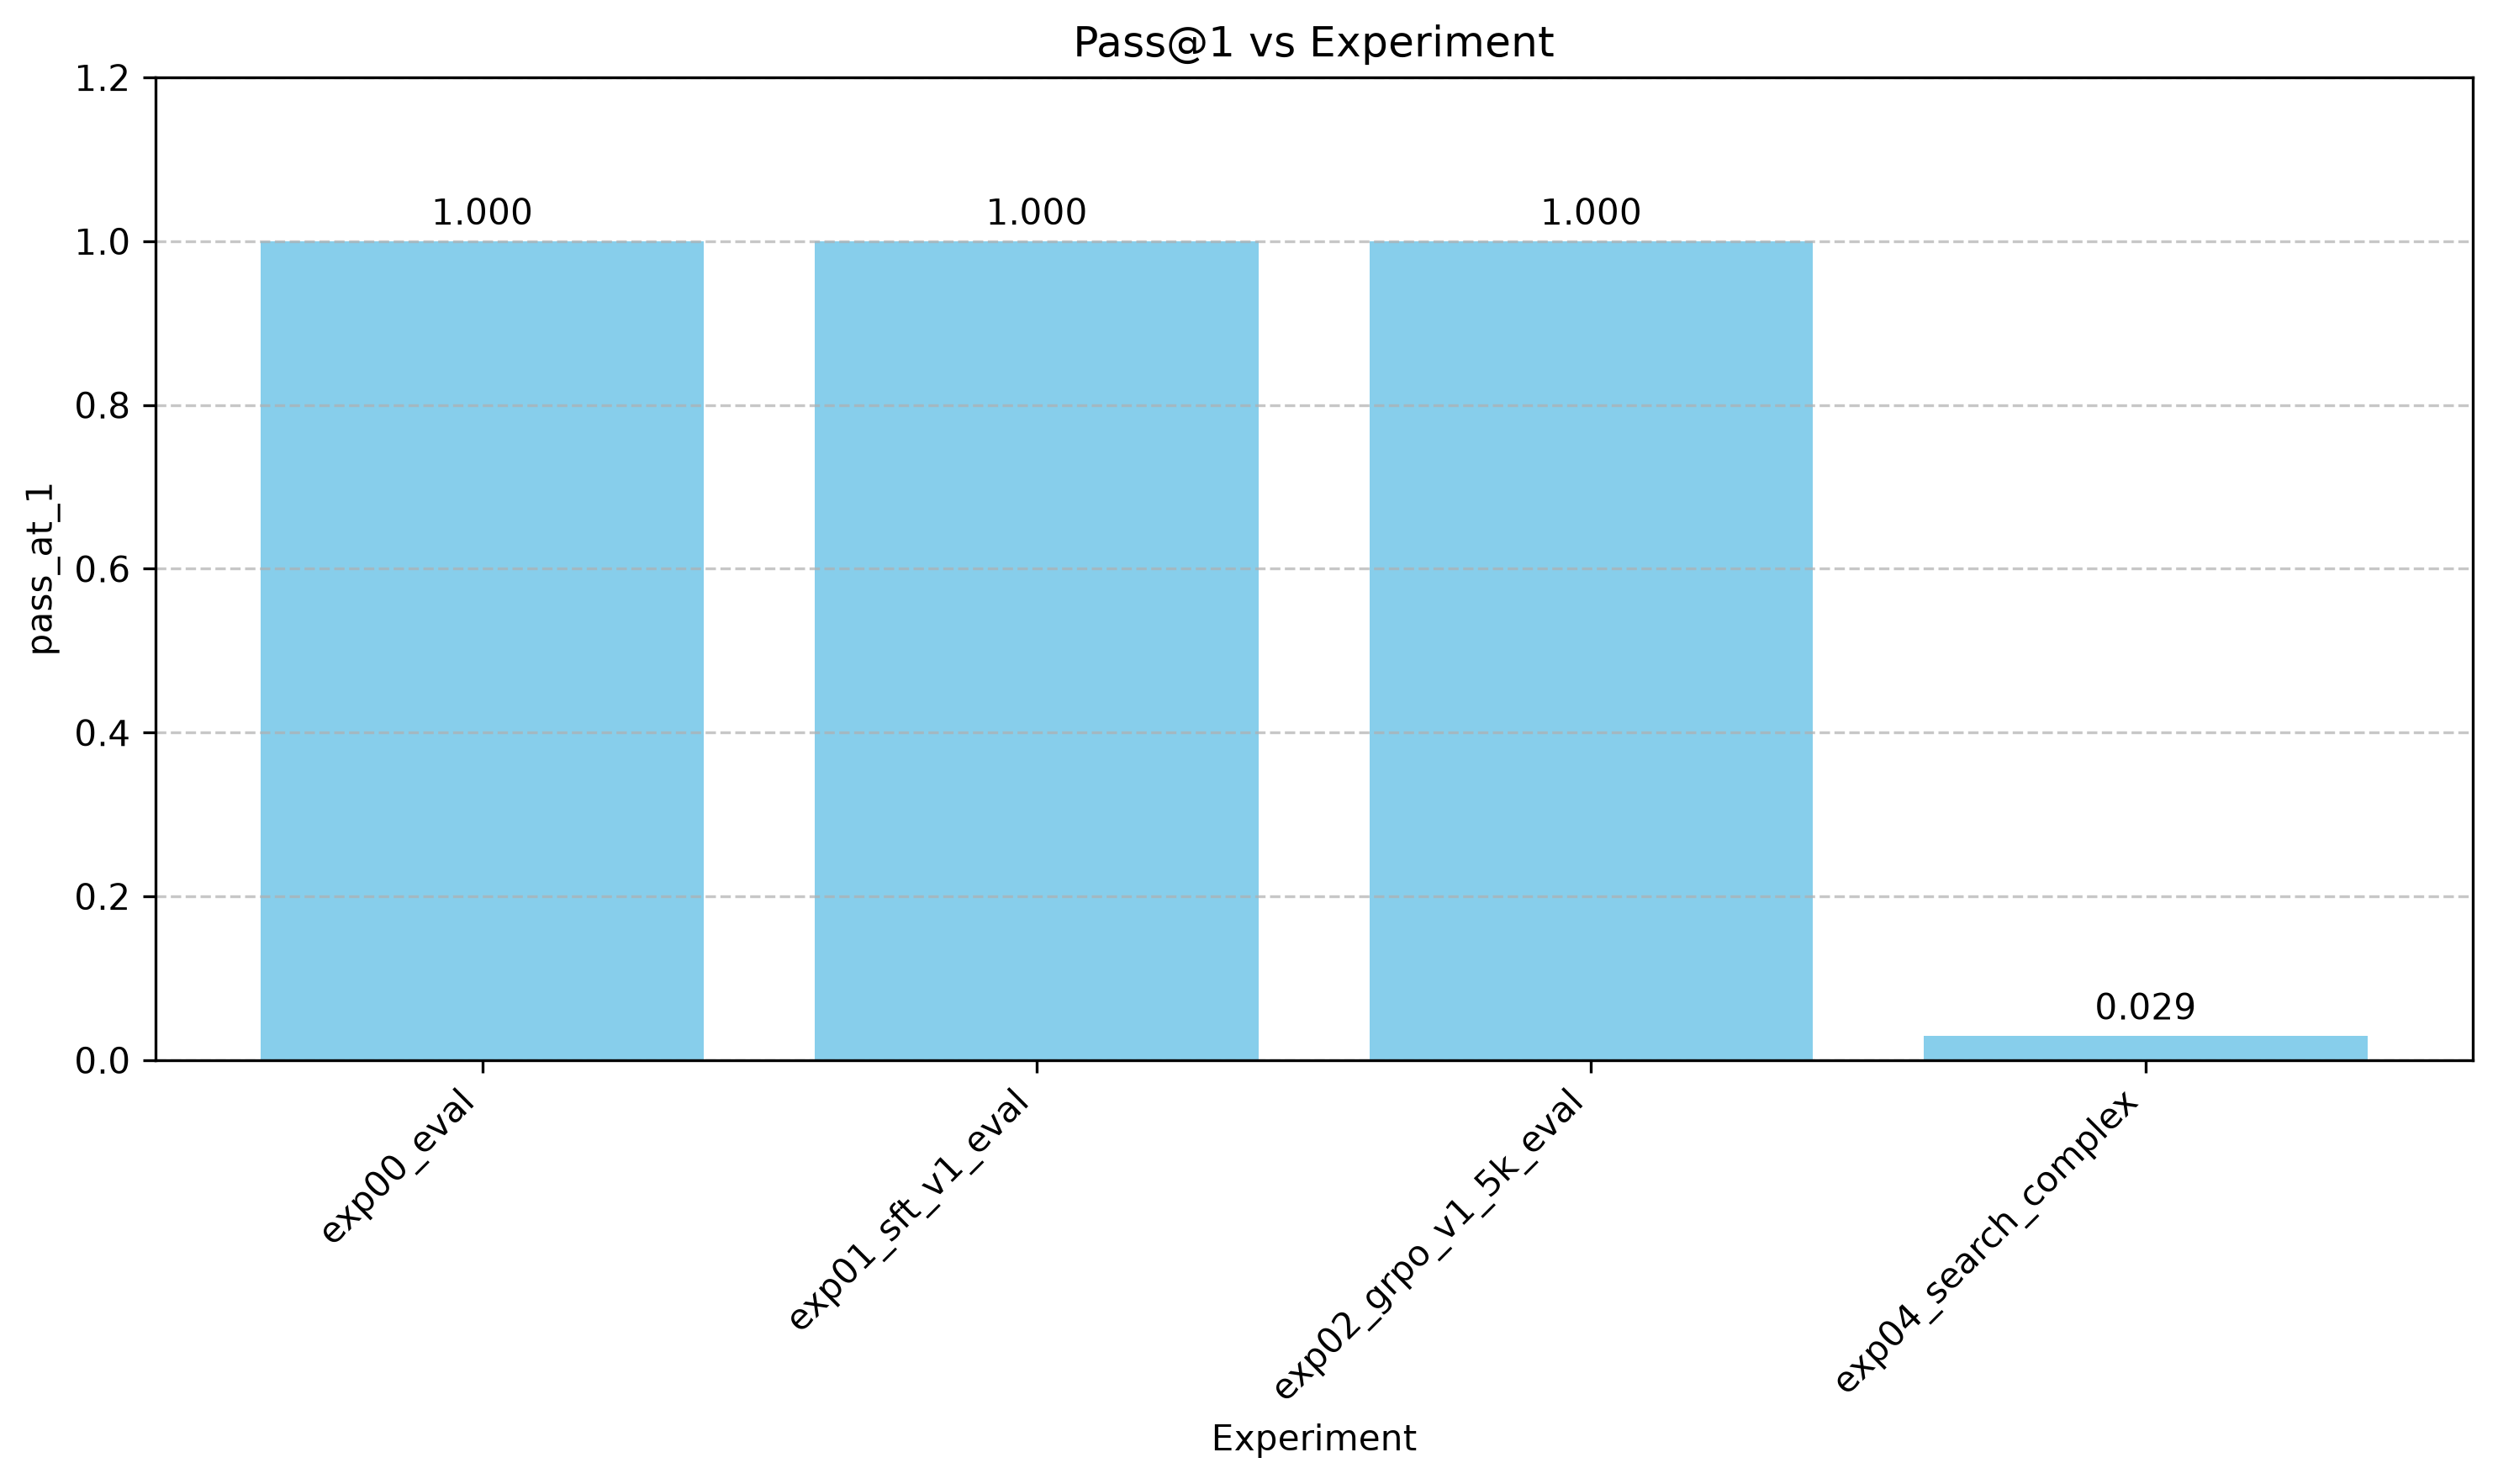

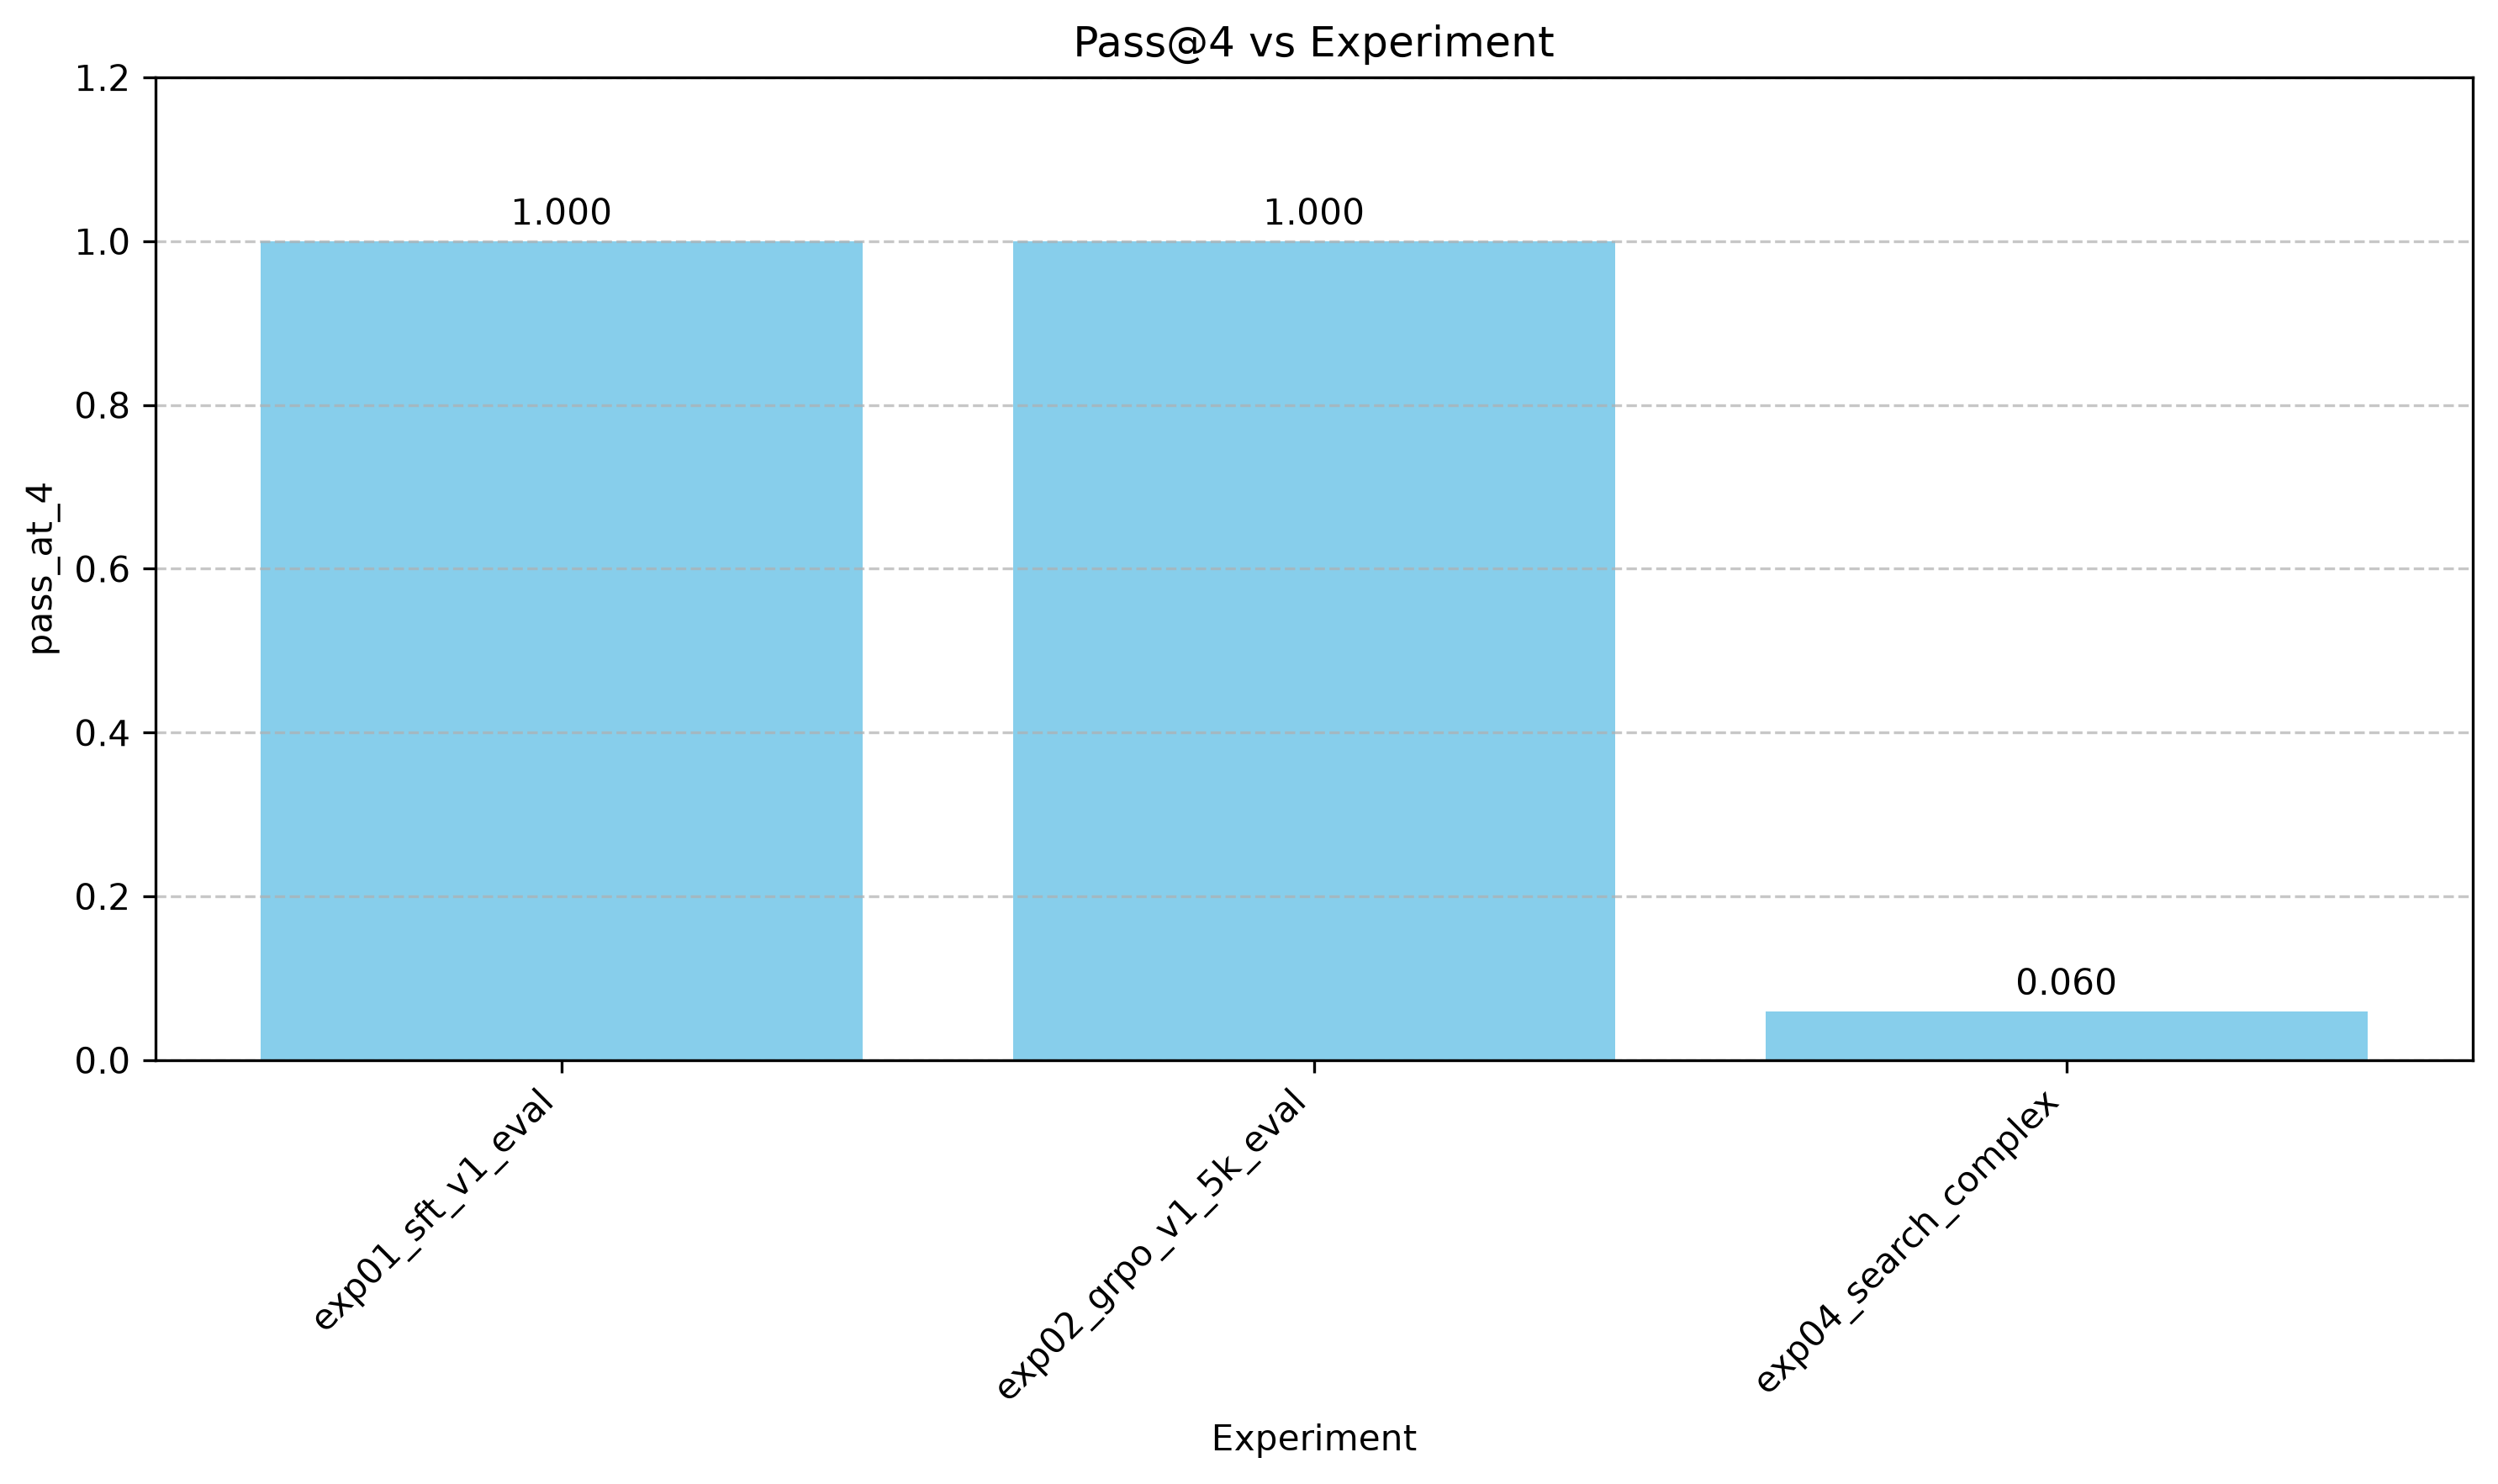

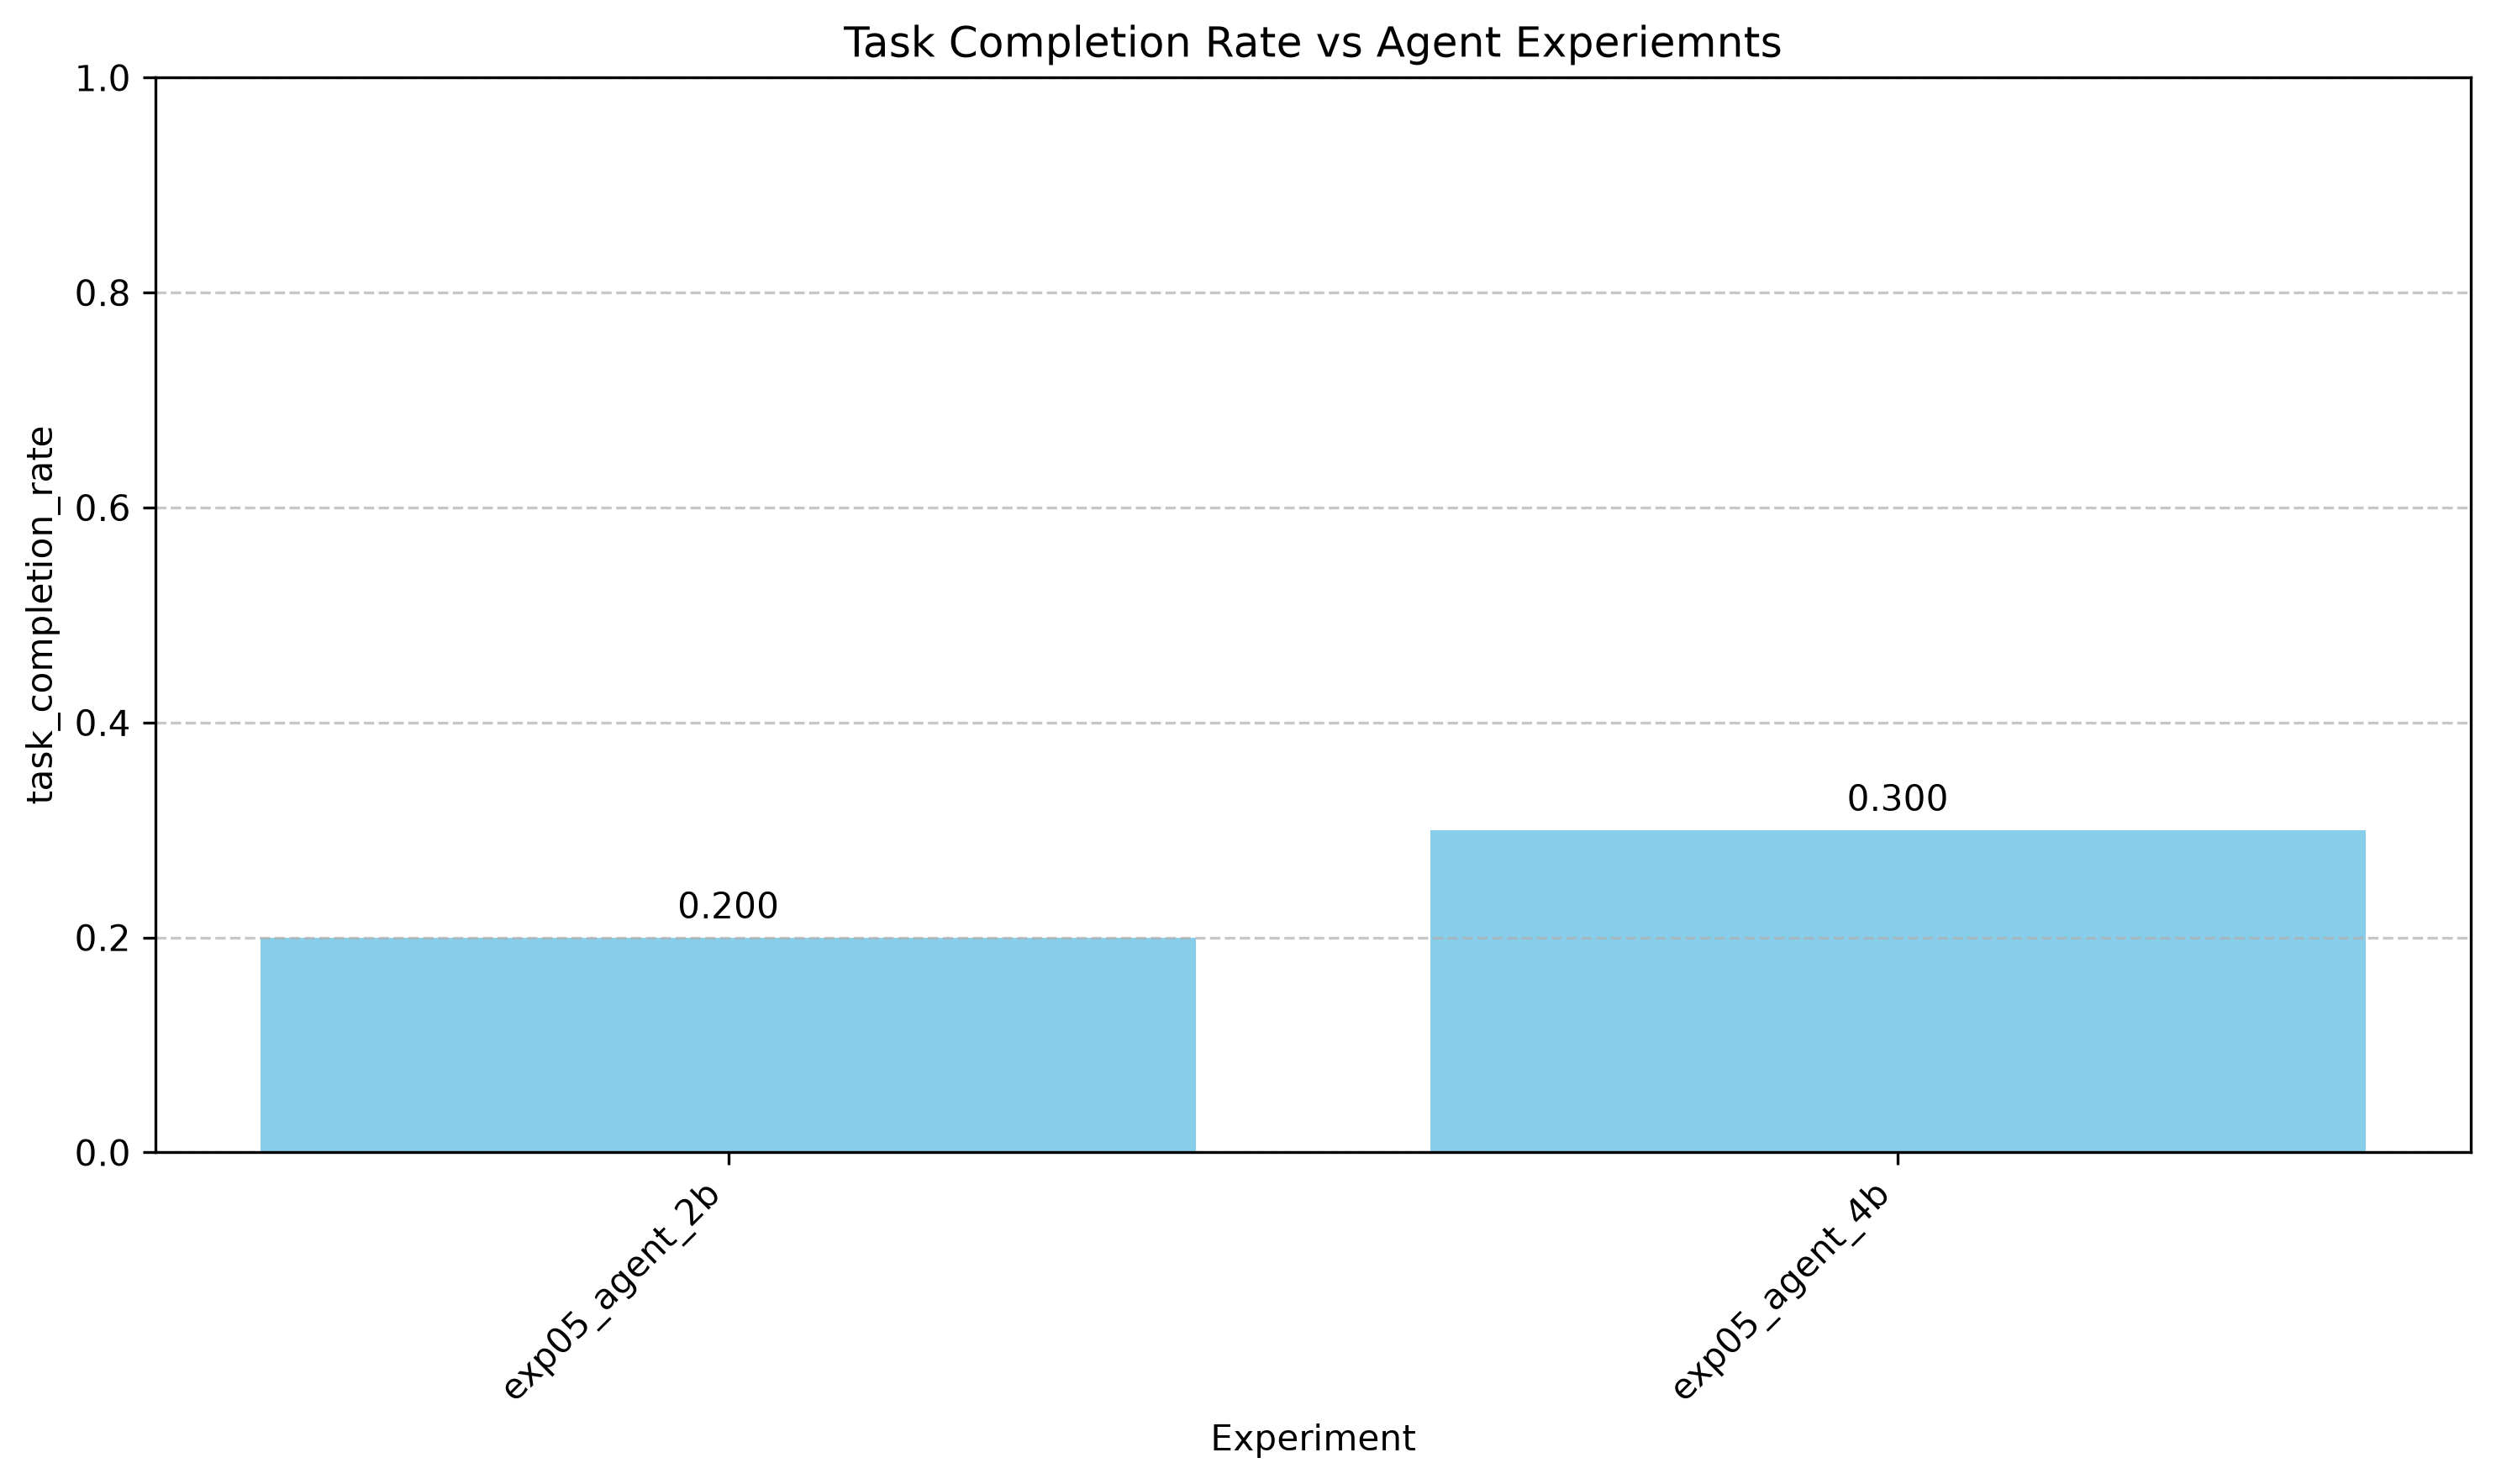

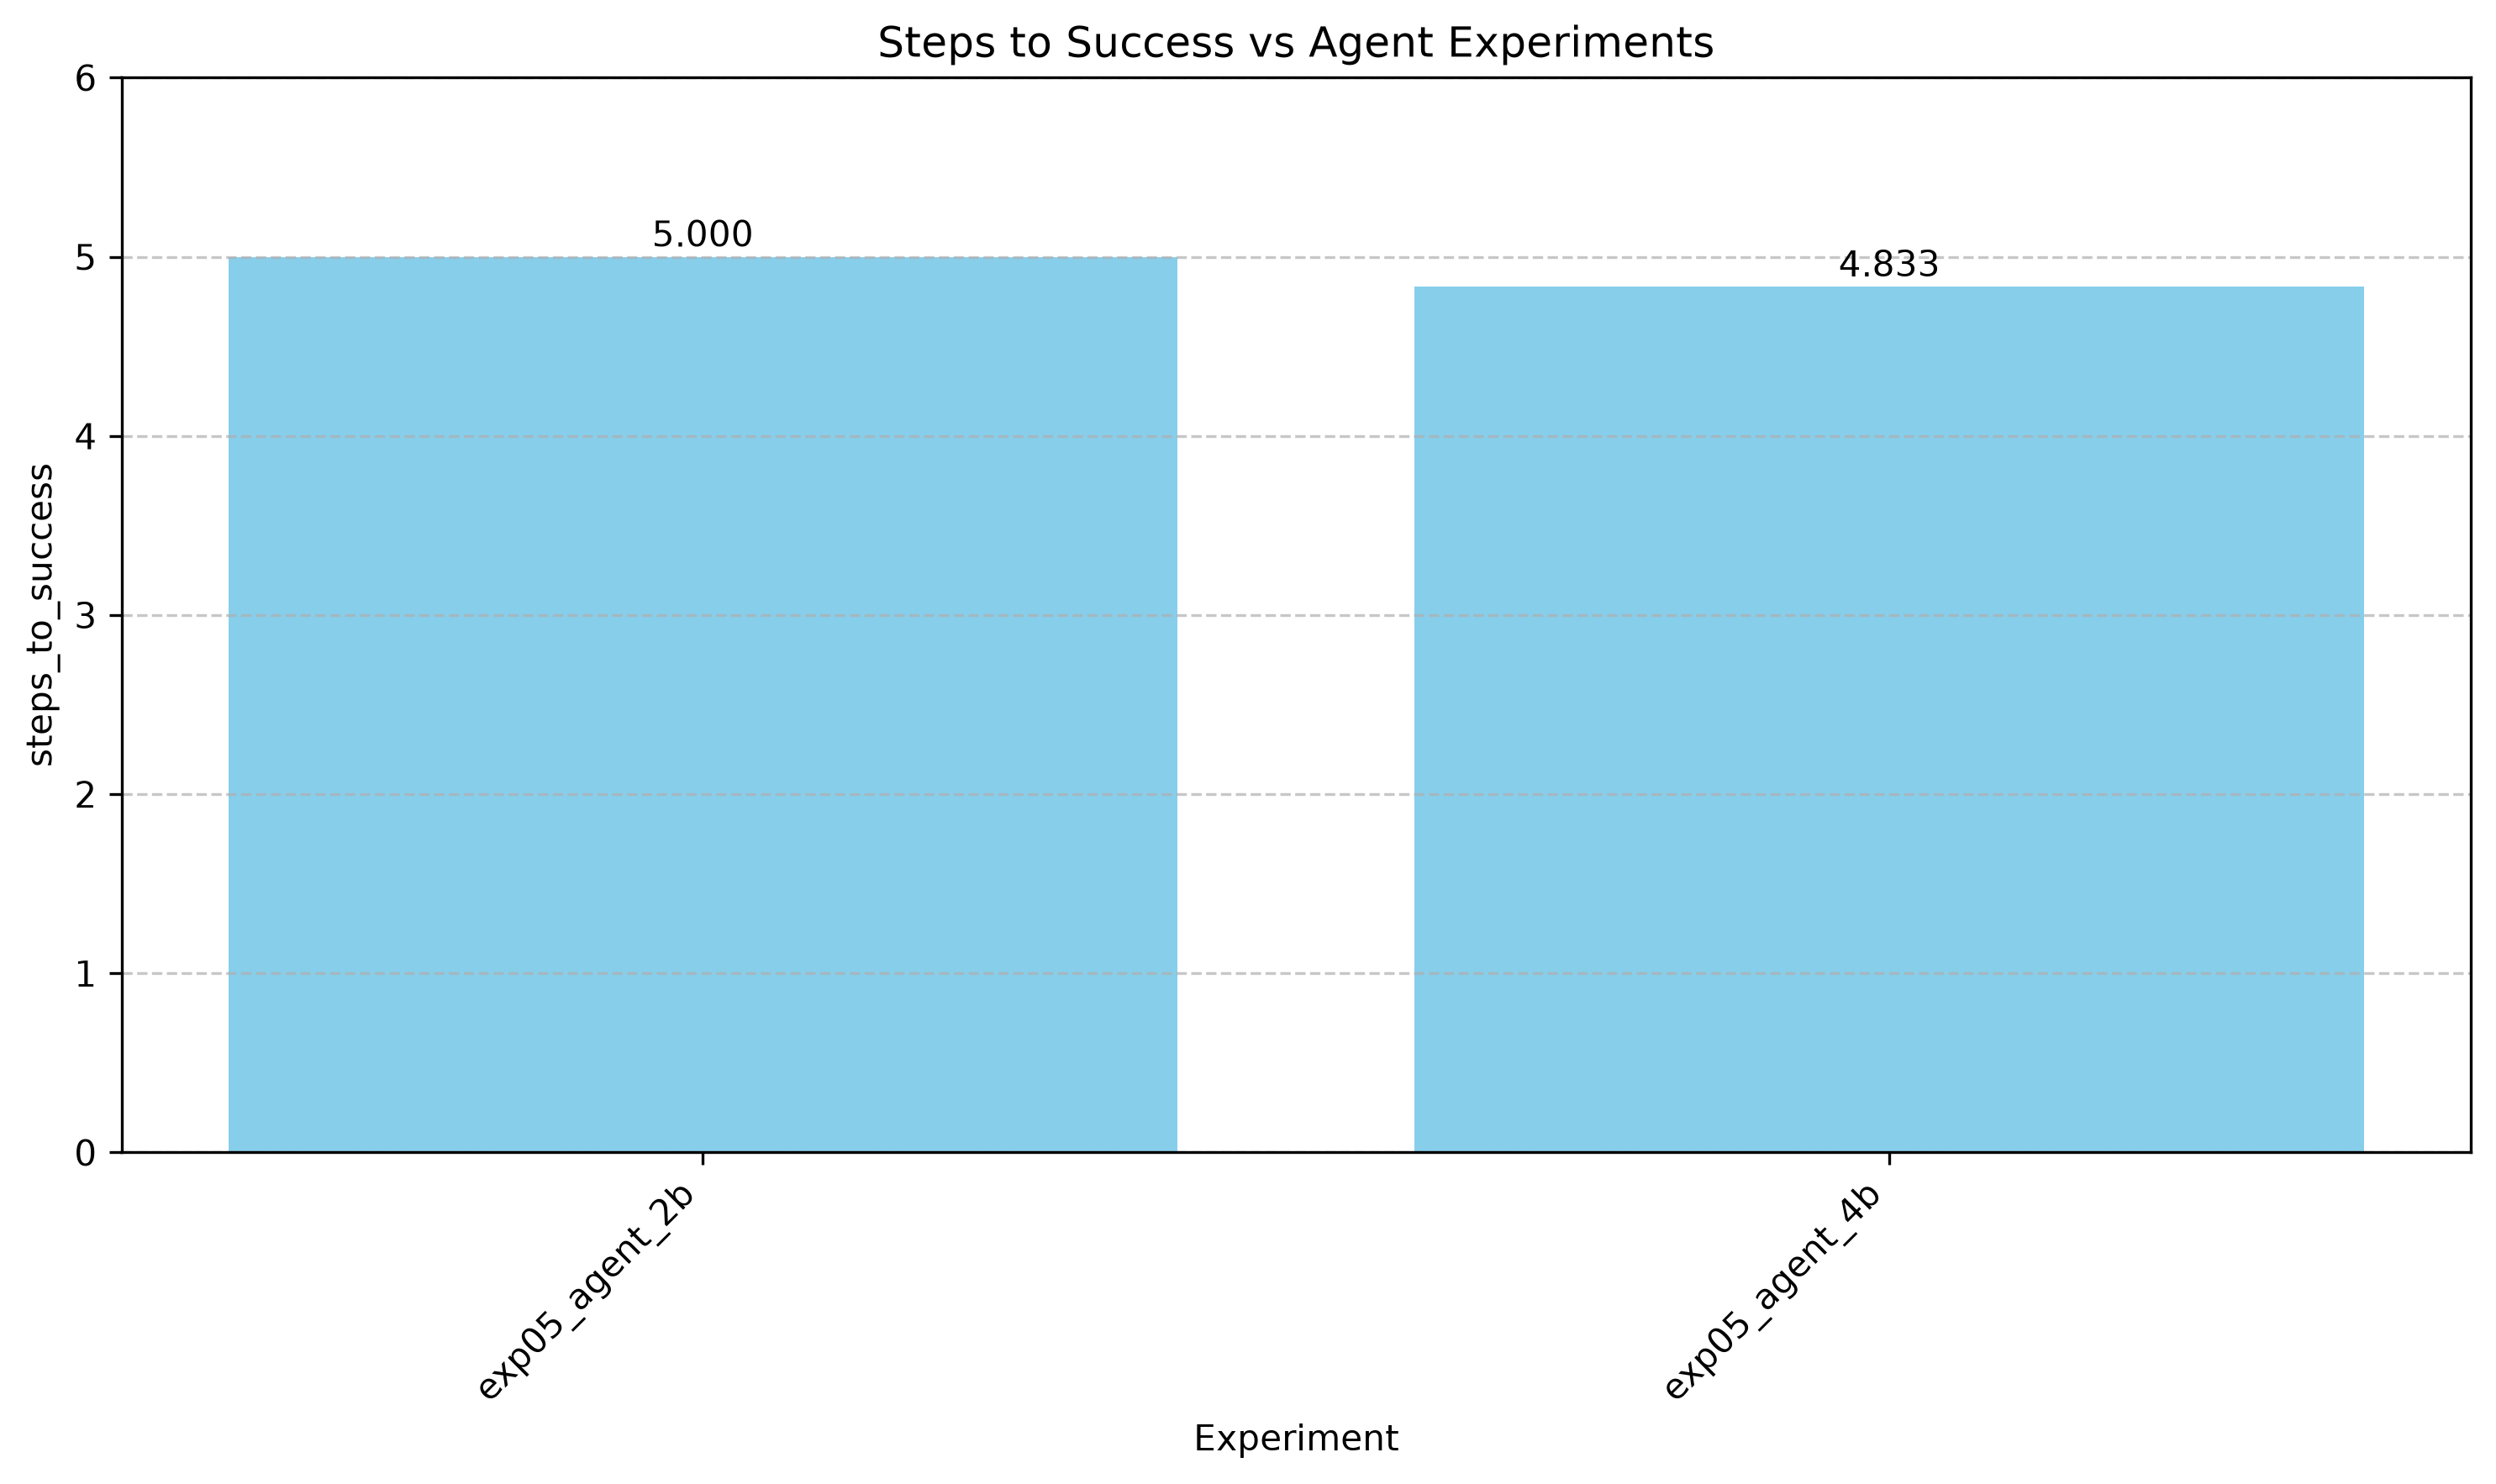

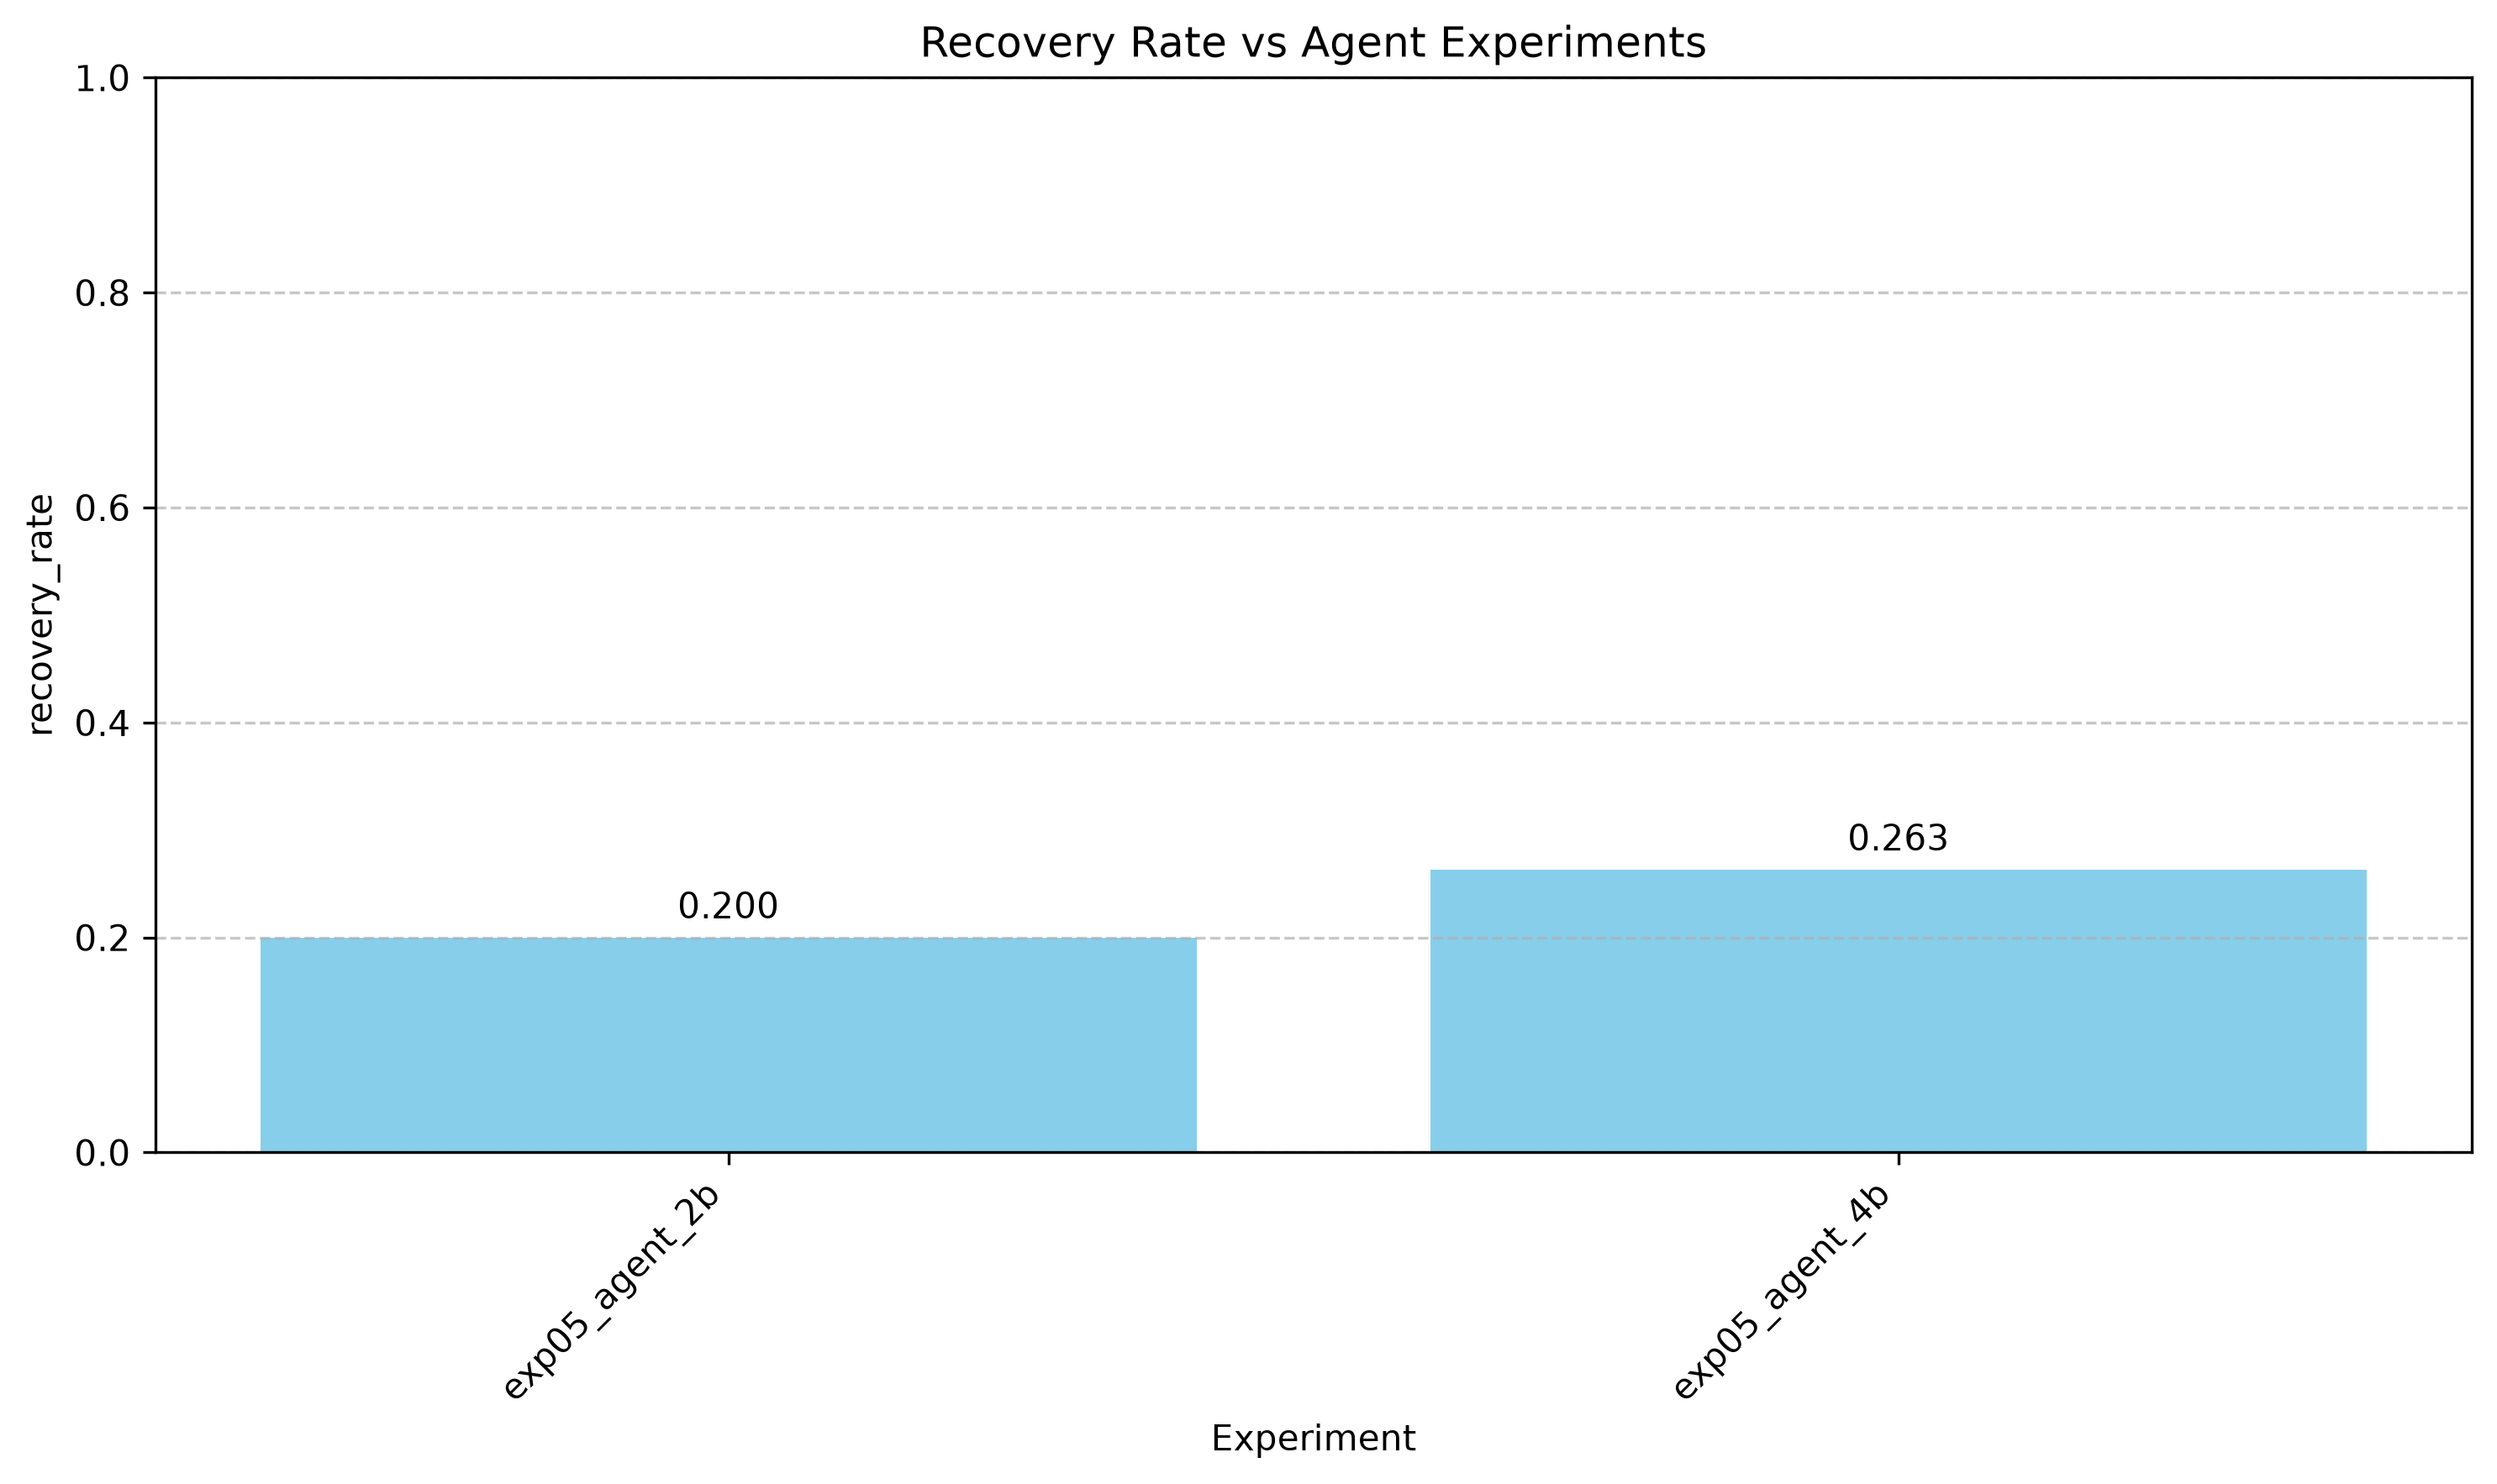

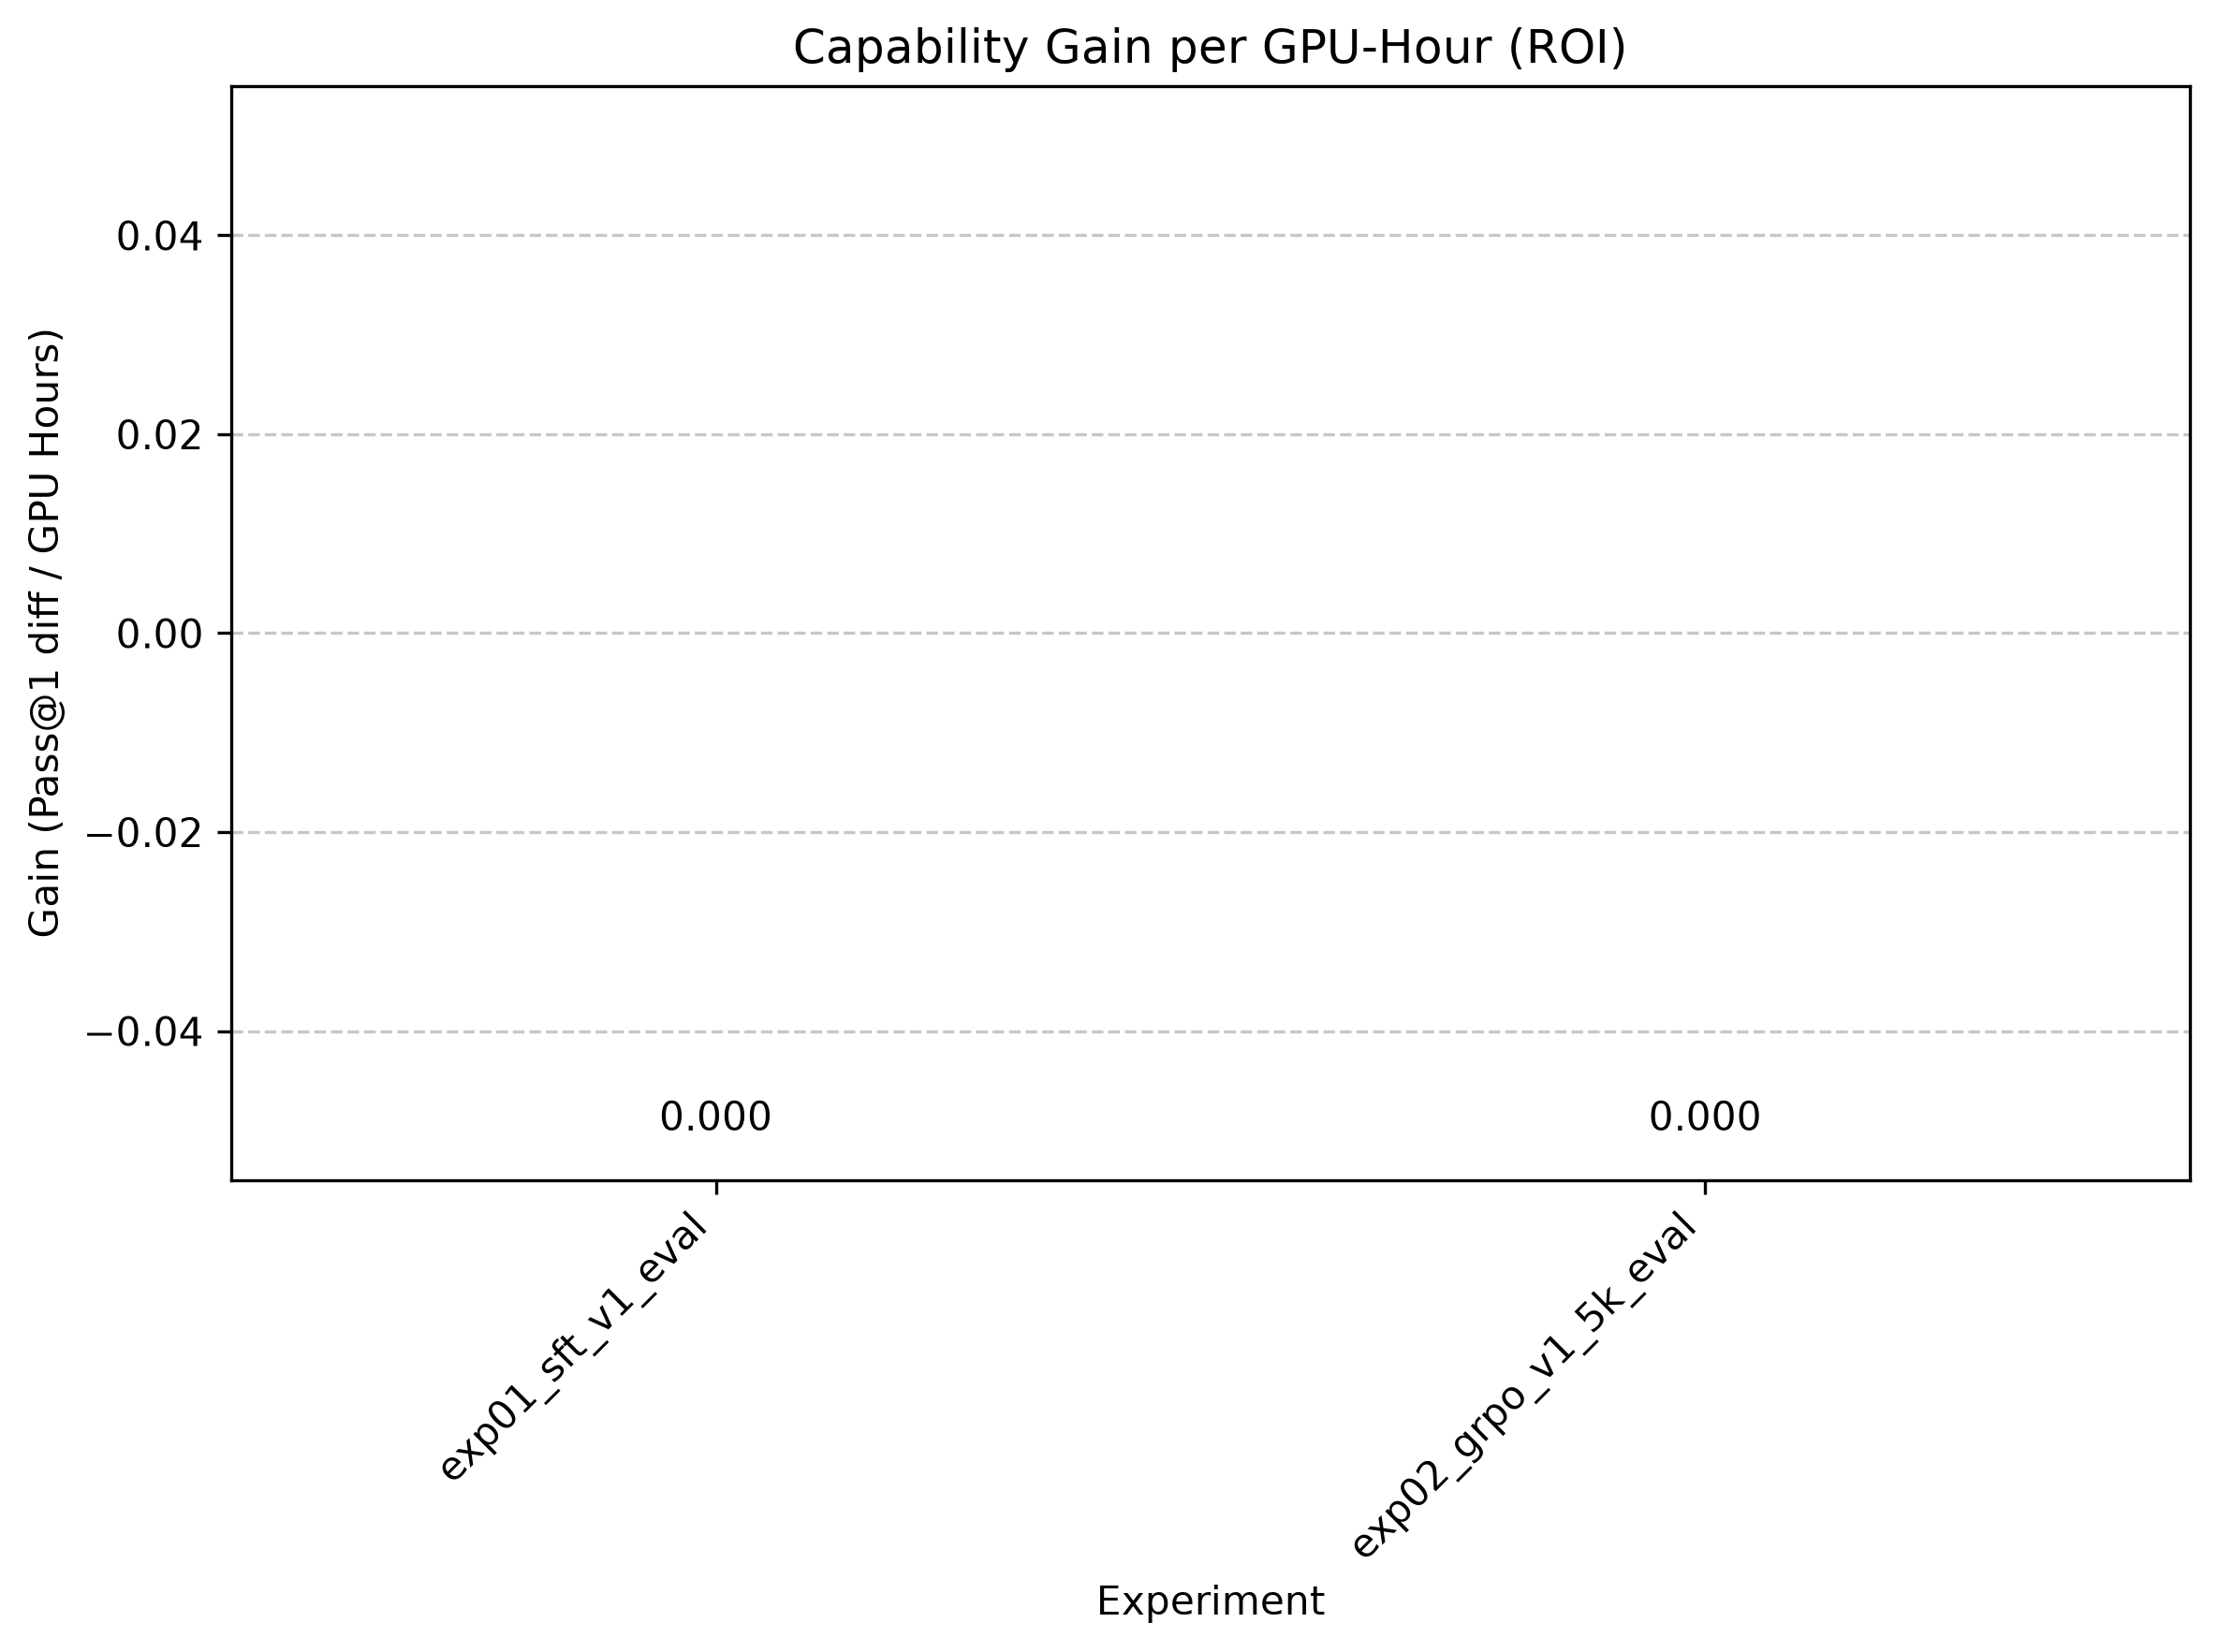

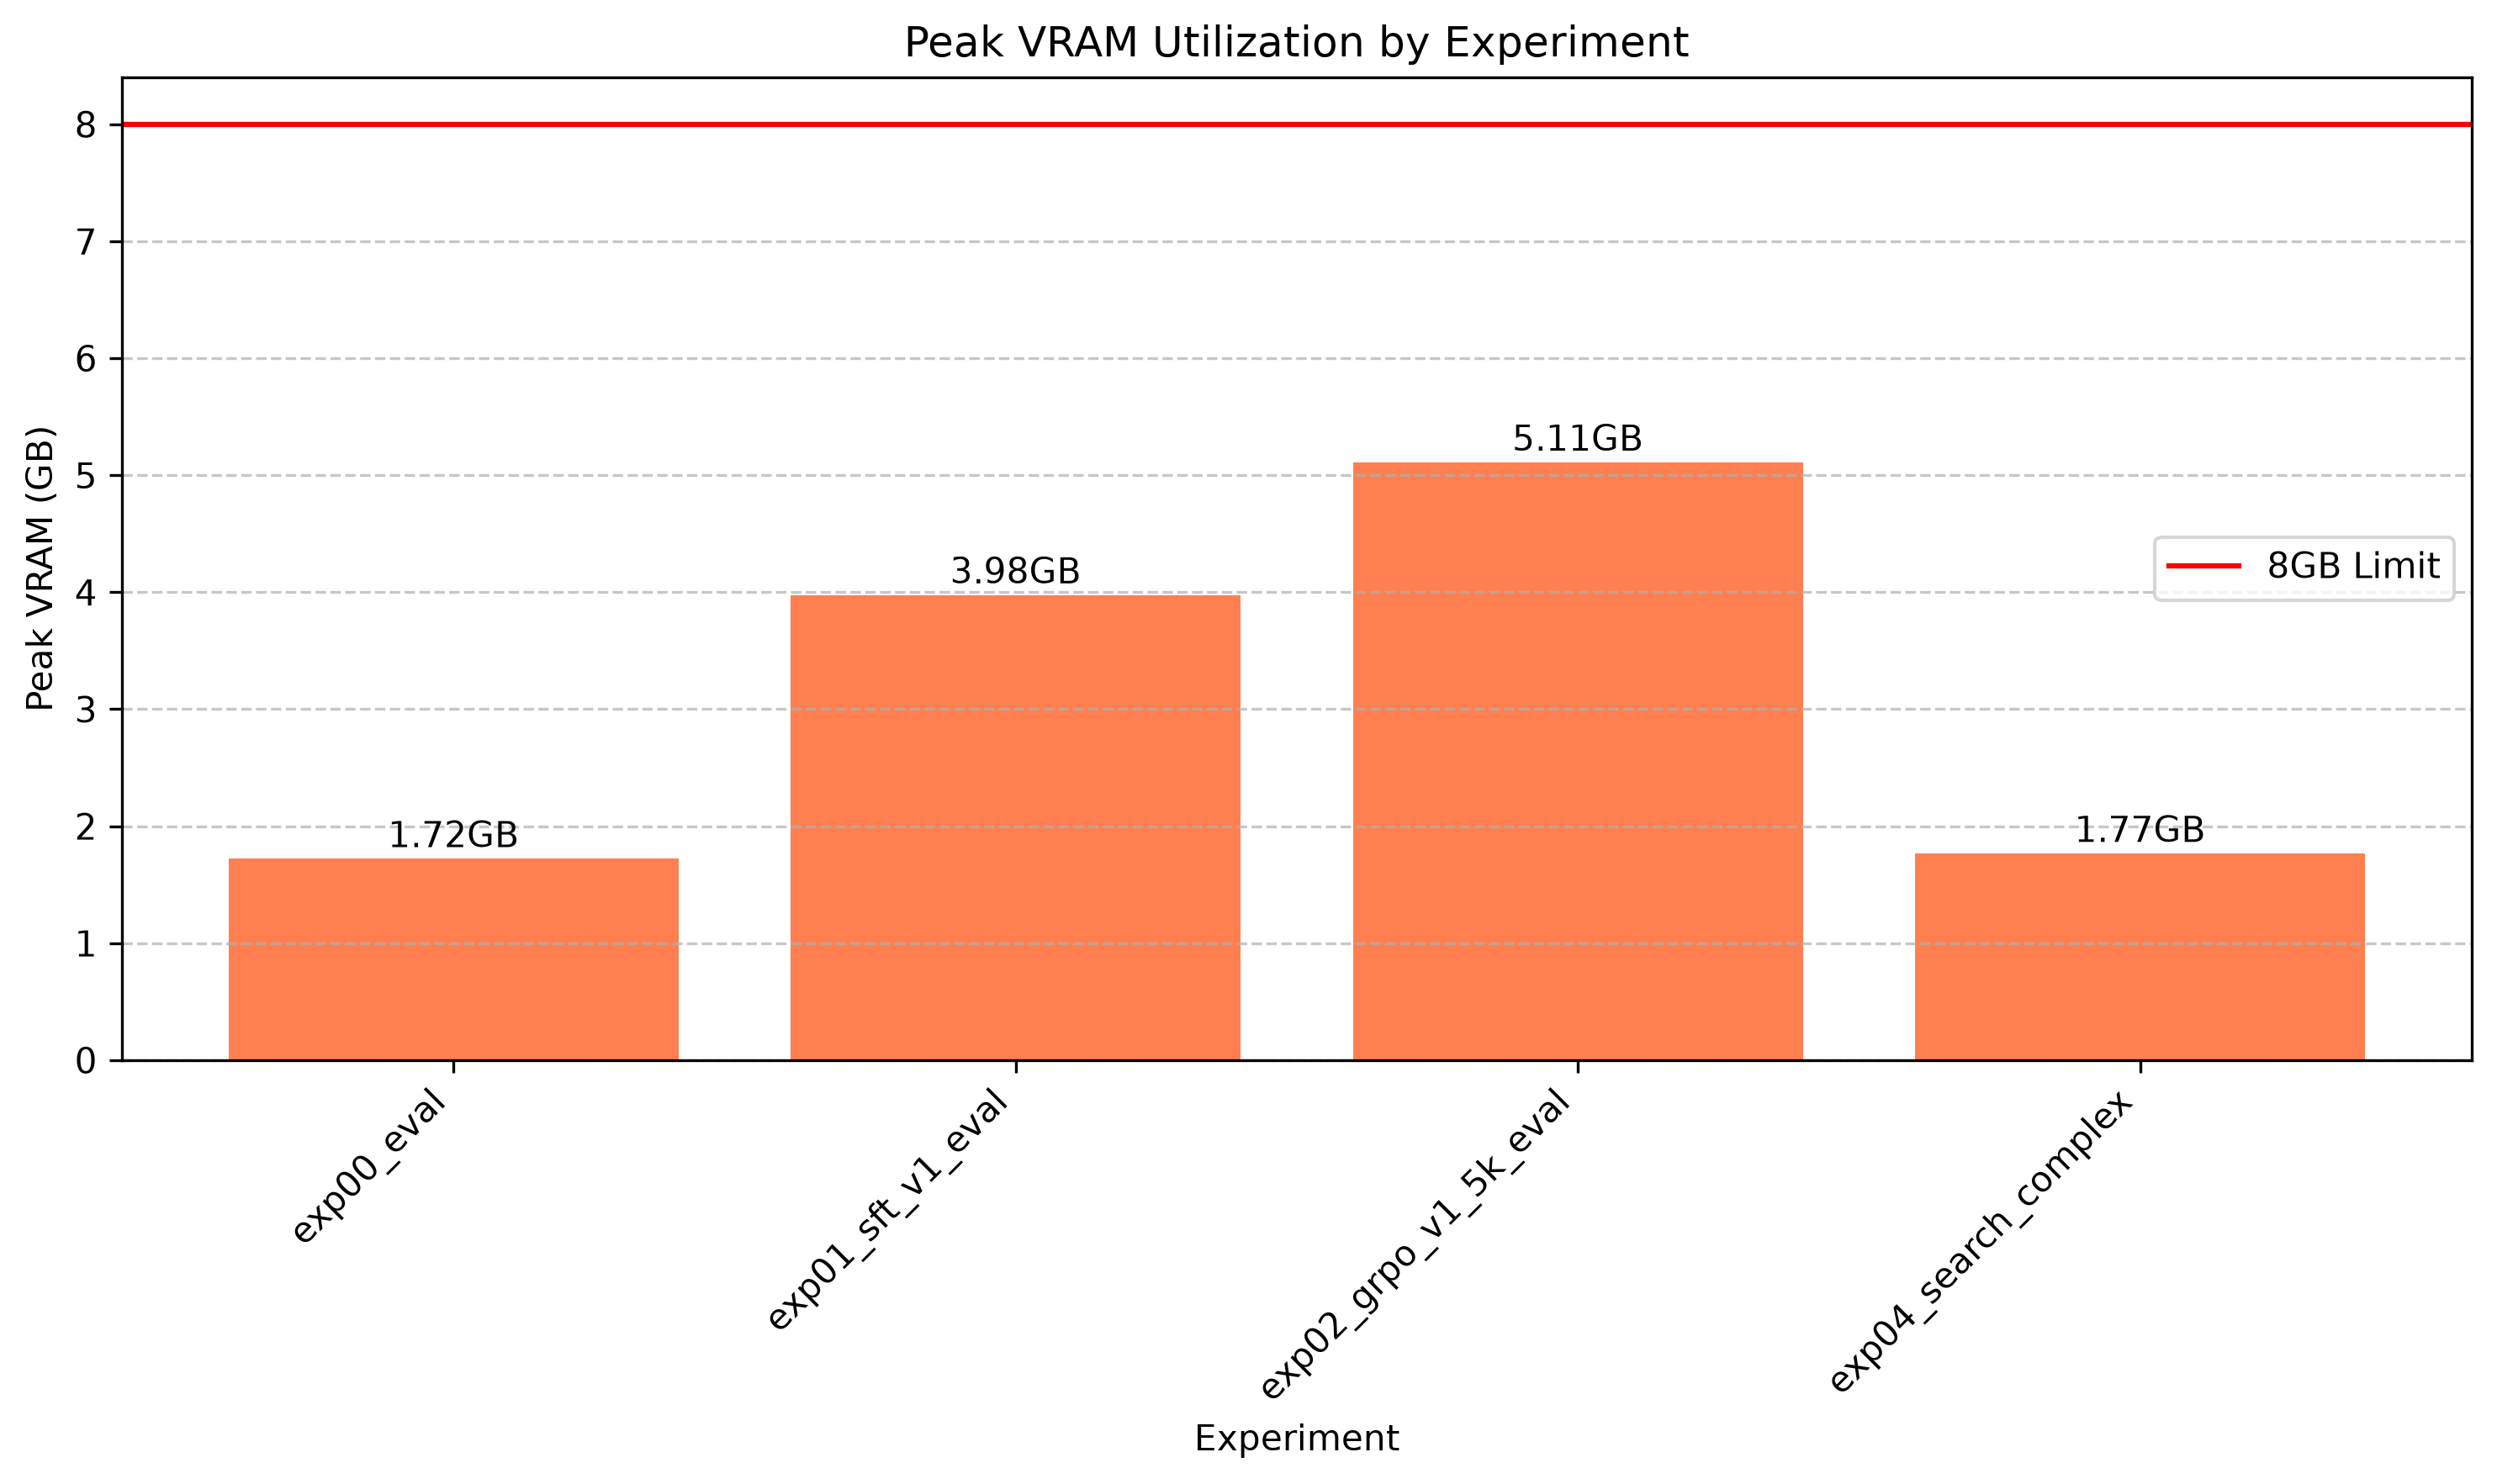

Figure pass_k_vs_compute.png not generated yet.


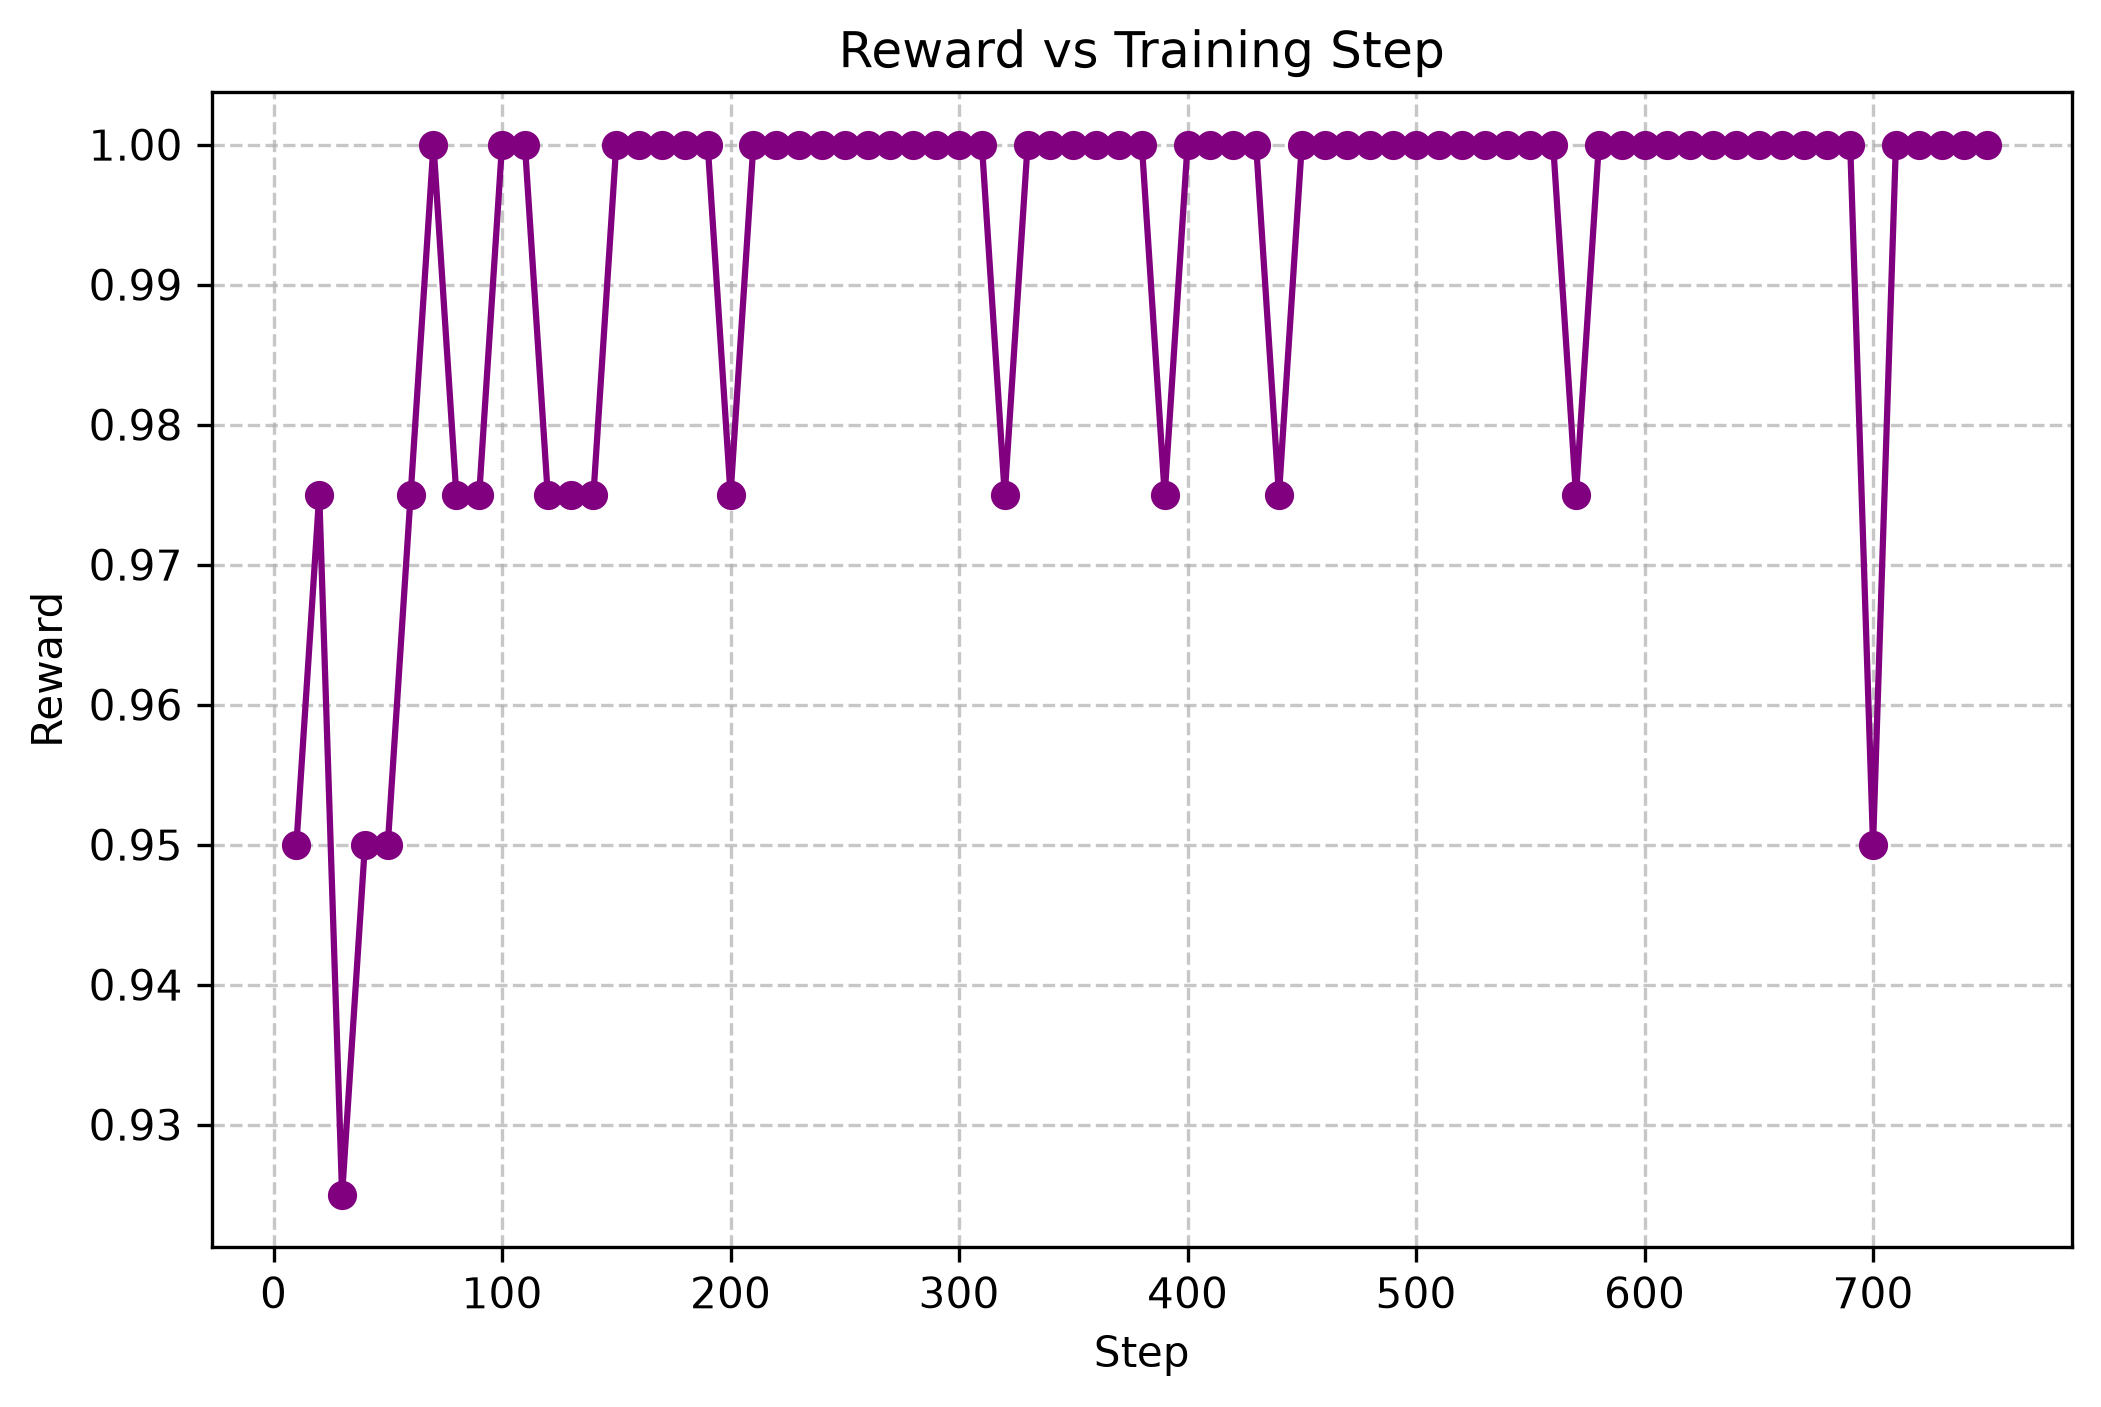

In [6]:
def show_image(name, width=800):
    path = Path(f"reports/figures/{name}")
    if path.exists():
        display(HTML(f'<h3>{name}</h3>'))
        display(Image(filename=str(path), width=width))
    else:
        print(f"Figure {name} not generated yet.")

# List of figures generated by dashboard.py
figures = [
    "pass_1_vs_exp.png",
    "pass_4_vs_exp.png",
    "task_completion_rate_vs_exp.png",
    "steps_to_success_vs_exp.png",
    "recovery_rate_vs_exp.png",
    "roi_gain_per_gpu_hour.png",
    "hardware_util.png",
    "pass_k_vs_compute.png",
    "reward_vs_step.png"
]

for fig in figures:
    show_image(fig)